# Data2001 - Assignment 1: Group 59

## Members:

1. SID: 520447042
2. SID:
3. SID:
4. SID: 

# Task 1:

In [6]:
import pandas as pd
import numpy as np

## Task 1.1: Load CSV File - COMPLETE

In [7]:
# Read in CSV and assign a name to the Series:
region = pd.read_csv("data/Region_summary_ New_South_ Wales_STE_1.csv")
region.name="NSW Regions"

## Task 1.2: Data Cleaning - TODO

### 1.2.1 Explore Dataframe 

In [8]:
# Check DataFrame structure and info:
print("Dataframe Information:")
print("name: \n\t",region.name)
print("Indices: \n\t", region.index)
print("Columns: \n\t", region.columns)
print("Shape: \n\t", region.shape)
print("Axes: \n\t", region.axes)
print("Data type: \n", region.dtypes)

Dataframe Information:
name: 
	 NSW Regions
Indices: 
	 RangeIndex(start=0, stop=800, step=1)
Columns: 
	 Index(['Measure Code', 'Parent Description', 'Description', '2011', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')
Shape: 
	 (800, 15)
Axes: 
	 [RangeIndex(start=0, stop=800, step=1), Index(['Measure Code', 'Parent Description', 'Description', '2011', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')]
Data type: 
 Measure Code           object
Parent Description     object
Description            object
2011                  float64
2015                  float64
2016                  float64
2017                  float64
2018                  float64
2019                  float64
2020                  float64
2021                  float64
2022                  float64
2023                  float64
2024                  float64
2025 

### 1.2.2 Clean the Data:

In [81]:
# Convert data into long format
# Where Year and Value have their own respecive columns.
region_long = region.melt(
    id_vars=["Measure Code", "Parent Description", "Description"], var_name="Year",value_name="Value"
)

In [82]:
region_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9600 entries, 0 to 9599
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Measure Code        9600 non-null   object 
 1   Parent Description  9600 non-null   object 
 2   Description         9600 non-null   object 
 3   Year                9600 non-null   object 
 4   Value               2874 non-null   float64
dtypes: float64(1), object(4)
memory usage: 375.1+ KB


In [83]:
count_non_missing = region_long.groupby("Year")["Value"].count()
total_rows = region_long.groupby("Year")["Value"].size()

missing = total_rows - count_non_missing
print("Number of missing entries per year:\n",missing)

Number of missing entries per year:
 Year
2011    541
2015    780
2016    343
2017    752
2018    675
2019    530
2020    509
2021    108
2022    507
2023    593
2024    591
2025    797
Name: Value, dtype: int64


In [84]:
#Check for Missing values:
# 6726 missing values
print(region_long.isna().sum())

Measure Code             0
Parent Description       0
Description              0
Year                     0
Value                 6726
dtype: int64


In [85]:
#Check if there are any duplicates 
print(region_long.duplicated().sum())

0


In [86]:
# Drop rows with missing values
# Missing values represent unavailable data, not zero population which is why rows with missing values were removed for analysis.
region_long_clean = region_long.dropna(subset=["Value"], ignore_index=True) # drop the rows with missing values

In [87]:
print(region_long_clean.isna().sum())

Measure Code          0
Parent Description    0
Description           0
Year                  0
Value                 0
dtype: int64


In [88]:
region_long_clean.head()

,Measure Code,Parent Description,Description,Year,Value
0,CENSUS_34,Aboriginal and Torres Strait Islander Peoples ...,Aboriginal and Torres Strait Islander Peoples ...,2011,172620.0
1,CENSUS_2,Aboriginal and Torres Strait Islander Peoples ...,Aboriginal and Torres Strait Islander Peoples (%),2011,2.5
2,CENSUS_15,Religious affiliation - Census,Buddhism (%),2011,2.9
3,CENSUS_16,Religious affiliation - Census,Christianity (%),2011,64.5
4,CENSUS_17,Religious affiliation - Census,Hinduism (%),2011,1.7


In [89]:
region_long_clean.groupby("Year")["Value"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2011,259.0,6.735284e+05,4.126540e+06,0.1,7.950,59.90,66214.00,53566048.0
2015,20.0,8.022549e+06,1.919068e+07,25.0,59.450,40790.50,3001437.50,80129856.0
2016,457.0,1.530573e+06,7.971771e+06,0.3,8.700,60.90,127179.00,80129856.0
2017,48.0,4.820513e+06,1.495873e+07,5.2,1094.500,14314.80,692153.50,80129856.0
2018,125.0,2.249978e+06,9.359767e+06,1.1,1125.000,42012.00,373693.00,80129856.0
2019,270.0,1.133374e+06,6.384606e+06,1.2,38.150,36056.00,255654.75,80129856.0
2020,291.0,1.103433e+06,6.072784e+06,1.2,52.500,36494.00,261412.50,80129856.0
2021,692.0,6.610403e+05,4.611798e+06,-16822.0,7.875,2956.45,151384.00,80079765.9
2022,293.0,3.916004e+05,1.148907e+06,-39335.0,60.000,41032.00,249894.00,8166704.0


## Task 1.3: Derived Statistics - TODO

### Group member 1 SID: 520447042

#### Stat 1: Max median across all years

In [90]:
#Find which year Had the nightest median value
max_median = []

for year, group in region_long_clean.groupby("Year"):
    max_median.append((year, int(group["Value"].median())))

max_year = max(max_median, key=lambda x: x[1])
print("Find which year Had the nightest median value:")
print(f"- {max_year[0]} had the highest median value of {max_year[1]}.")
# print(max_medan)

Find which year Had the nightest median value:
- 2018 had the highest median value of 42012.


#### Stat 2:

Text(0.5, 1.0, 'Num of Jobs in Aus - accommodation & food services 2018-2022')

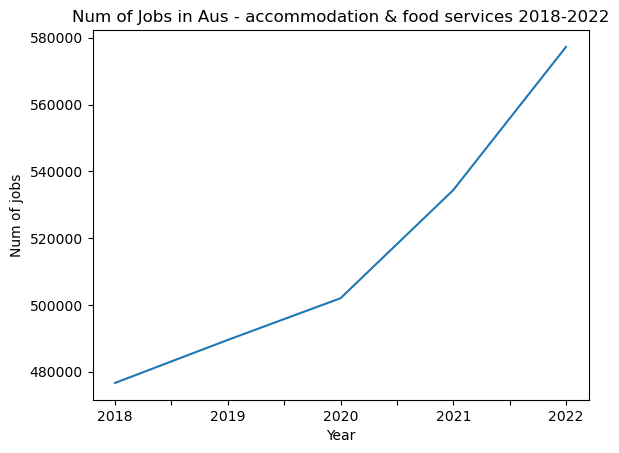

In [93]:
# Plot the mean values for each year.
plot = region_long_clean[
    region_long_clean["Measure Code"] == "LEED_12"
].groupby("Year")["Value"].mean().plot()

plot.set_xlabel("Year")
plot.set_ylabel("Num of jobs")
plot.set_title("Num of Jobs in Aus - accommodation & food services 2018-2022")

#### Stat 3:

In [92]:
print(region_long_clean[region_long_clean["Measure Code"] == "CENSUS_34"])

     Measure Code                                 Parent Description  \
0       CENSUS_34  Aboriginal and Torres Strait Islander Peoples ...   
279     CENSUS_34  Aboriginal and Torres Strait Islander Peoples ...   
1597    CENSUS_34  Aboriginal and Torres Strait Islander Peoples ...   

                                            Description  Year     Value  
0     Aboriginal and Torres Strait Islander Peoples ...  2011  172620.0  
279   Aboriginal and Torres Strait Islander Peoples ...  2016  216171.0  
1597  Aboriginal and Torres Strait Islander Peoples ...  2021  278043.0  


#### Stat 4:

#### Stat 5:

### Group member 2 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

#### Stat 5:

### Group member 3 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

In [59]:
#### Stat 5:

### Group member 4 SID:

#### Stat 1:

#### Stat 2:

#### Stat 3:

#### Stat 4:

#### Stat 5:

# Task 2: API Data Collection - TO DO

## Task 2: Load in NSW Points of Interest API - TO DO

### Link to the API website: https://datasets.seed.nsw.gov.au/dataset/nsw-points-of-interest-poi

1. isolate an area box using longtitude and latitude
2. Find all POIs in chosen area
3. do analysis (check all these as i am doing this from memory)

## Task 2: Develop Function - TO DO

## Task 2: Build Loop - TO DO

## Task 2: Add results to Database - TO DO

# Task 3: Compute Scores - TO DO

# Task 4: Prepare Report - TO DO

# Task 5: Brief Conversation with Tutor - TO DO

# Deliverables - TO DO

1. PDF Report  - Google Doc: link in READ ME and : https://docs.google.com/document/d/1n2X06f8SsJrVs9xzTqE0d5J3EYx_cJwz28PFvmnBcf0/edit?usp=sharing
2. Juytper Notebook - THIS
3. Convo with tutor